<a href="https://colab.research.google.com/github/27abernal/Adv_AI/blob/main/AI_Final_Project_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Imports
from google.colab import files
import io
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
from sklearn.tree import plot_tree

# For class imbalance
from imblearn.over_sampling import SMOTE

print("All imports successful!")

All imports successful!


In [ ]:
# Cell 2: Load the Dataset
# file picker
uploaded = files.upload()

# read file
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataset loaded: 7043 rows, 21 columns

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Cell 3: Initial Data Exploration
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution ===")
churn_counts = df['Churn'].value_counts()
churn_rate = (df['Churn'] == 'Yes').mean()
print(f"Churn - Yes: {churn_counts.get('Yes', 0)} ({churn_rate:.2%})")
print(f"Churn - No: {churn_counts.get('No', 0)} ({1-churn_rate:.2%})")
print(f"Imbalance ratio: {1/churn_rate:.2f}:1")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  704

In [ ]:
# Cell 4: Basic Cleaning
# Drop customerID (unique identifier, not useful for prediction)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
    print("Dropped 'customerID' column")

# Convert TotalCharges to numeric (coerce errors to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing TotalCharges with median
missing_before = df['TotalCharges'].isnull().sum()
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print(f"Filled {missing_before} missing values in TotalCharges with median")

print("\nBasic cleaning complete.")

Dropped 'customerID' column
Filled 11 missing values in TotalCharges with median

Basic cleaning complete.


In [ ]:
# Cell 5: Simplify Service Columns
cols_to_fix = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
               'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in cols_to_fix:
    df[col] = df[col].replace('No internet service', 'No')
    print(f"Fixed '{col}'")

df['MultipleLines'] = df['MultipleLines'].replace('No phone service', 'No')
print("Fixed 'MultipleLines'")

print("\nService column simplification complete.")

Fixed 'OnlineSecurity'
Fixed 'OnlineBackup'
Fixed 'DeviceProtection'
Fixed 'TechSupport'
Fixed 'StreamingTV'
Fixed 'StreamingMovies'
Fixed 'MultipleLines'

Service column simplification complete.


In [ ]:
# Cell 6: Advanced Feature Engineering
print("=== Creating New Features ===")

# Original features (keep these)
df['ServiceCount'] = (df[cols_to_fix] == 'Yes').sum(axis=1)
df['ServiceDensity'] = df['ServiceCount'] / 6
df['ChargeRatio'] = df['TotalCharges'] / (df['tenure'] + 1)
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

# NEW FEATURE 1: Average monthly spend over tenure
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

# NEW FEATURE 2: Senior citizen with month-to-month contract (high risk combo)
df['SeniorMonthToMonth'] = ((df['SeniorCitizen'] == 1) &
                             (df['Contract'] == 'Month-to-month')).astype(int)

# NEW FEATURE 3: No online security AND no tech support (double risk)
df['NoProtection'] = ((df['OnlineSecurity'] == 'No') &
                      (df['TechSupport'] == 'No')).astype(int)

# NEW FEATURE 4: Fiber optic + month-to-month (expensive + risky)
df['FiberMonthToMonth'] = ((df['InternetService'] == 'Fiber optic') &
                           (df['Contract'] == 'Month-to-month')).astype(int)

# NEW FEATURE 5: Electronic check payment (known risk factor)
df['ElectronicCheck'] = (df['PaymentMethod'] == 'Electronic check').astype(int)

# NEW FEATURE 6: Long tenure customer (>24 months)
df['IsLongTenure'] = (df['tenure'] > 24).astype(int)

# SIMPLIFIED TenureGroup (3 categories instead of 4)
bins = [0, 12, 37, 100]  # Low: 0-12, Medium: 13-36, High: 37+
labels = ['Low', 'Medium', 'High']
df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

print(f"Added 9 new features. Total columns now: {len(df.columns)}")
print("\nNew features created:")
print("- ServiceCount, ServiceDensity, ChargeRatio, IsNewCustomer")
print("- AvgMonthlySpend, SeniorMonthToMonth, NoProtection")
print("- FiberMonthToMonth, ElectronicCheck, IsLongTenure, TenureGroup")

=== Creating New Features ===
Added 9 new features. Total columns now: 31

New features created:
- ServiceCount, ServiceDensity, ChargeRatio, IsNewCustomer
- AvgMonthlySpend, SeniorMonthToMonth, NoProtection
- FiberMonthToMonth, ElectronicCheck, IsLongTenure, TenureGroup


In [ ]:
# Cell 7: Data Quality Checks
print("=== Data Quality Checks ===\n")

# Check for zero or negative charges
zero_monthly = (df['MonthlyCharges'] <= 0).sum()
zero_total_but_tenure = ((df['TotalCharges'] <= 0) & (df['tenure'] > 0)).sum()
print(f"Zero or negative MonthlyCharges: {zero_monthly}")
print(f"Zero TotalCharges but tenure>0: {zero_total_but_tenure}")

# Check for outliers
print("\n=== Numerical Features Statistics ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

# Check class imbalance again after any changes
churn_rate = (df['Churn'] == 'Yes').mean()
print(f"\n=== Final Churn Rate ===")
print(f"Churn rate: {churn_rate:.2%}")
print(f"Imbalance ratio: {1/churn_rate:.2f}:1")

=== Data Quality Checks ===

Zero or negative MonthlyCharges: 0
Zero TotalCharges but tenure>0: 0

=== Numerical Features Statistics ===
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2281.916928
std      24.559481       30.090047   2265.270398
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    402.225000
50%      29.000000       70.350000   1397.475000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000

=== Final Churn Rate ===
Churn rate: 26.54%
Imbalance ratio: 3.77:1


In [ ]:
# Cell 8: Encode Target Variable
# Convert Churn to binary (Yes -> 1, No -> 0)
if df['Churn'].dtype == 'object':
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    print("Encoded Churn: Yes=1, No=0")

print(f"Target distribution:\n{df['Churn'].value_counts()}")

Encoded Churn: Yes=1, No=0
Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
# Cell 9: One-Hot Encoding
print(f"Before encoding: {len(df.columns)} columns")

# One-hot encoding for all remaining categorical variables
df_encoded = pd.get_dummies(df, drop_first=False)  # drop_first=False for clarity
df_encoded.dropna(inplace=True)

print(f"After encoding: {len(df_encoded.columns)} columns")
print(f"Final dataset shape: {df_encoded.shape}")

Before encoding: 31 columns
After encoding: 52 columns
Final dataset shape: (7043, 52)


In [ ]:
# Cell 10: Train-Test Split
# Split into Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Stratified split to keep churn proportions balanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"\nTraining churn rate: {y_train.mean():.2%}")
print(f"Testing churn rate: {y_test.mean():.2%}")

Training set shape: (5634, 51)
Testing set shape: (1409, 51)

Training churn rate: 26.54%
Testing churn rate: 26.54%


In [ ]:
# Cell 11: Random Forest Hyperparameter Tuning
print("=== Random Forest Hyperparameter Tuning ===\n")

param_grid = {
    'max_depth': [5, 8, 10],
    'n_estimators': [100, 200, 300],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='f1',
    cv=5,  # Increased from 3 to 5 for better validation
    verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print(f"\nBest Parameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

=== Random Forest Hyperparameter Tuning ===

Starting Grid Search...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters Found: {'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 300}
Best Cross-Validation F1 Score: 0.6392


=== Random Forest Evaluation ===

Performance at different thresholds:
 threshold  f1_score   recall
      0.35  0.606635 0.855615
      0.40  0.627649 0.831551
      0.45  0.638298 0.802139
      0.50  0.635452 0.762032
      0.55  0.634660 0.724599

--- Random Forest Report (Threshold: 0.45) ---
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.80      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409

ROC-AUC Score: 0.8448

Percentage of test set predicted as churn: 40.2%
Actual churn rate in test set: 26.5%


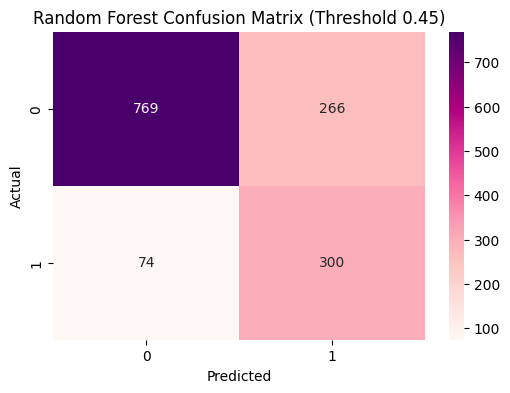

In [ ]:
# Cell 12: Random Forest Evaluation - Compare Thresholds (Lower Range)
print("=== Random Forest Evaluation ===\n")

# Get probabilities
y_probs = best_rf.predict_proba(X_test)[:, 1]  # Using best_rf

# Test lower thresholds to catch more churn
thresholds = [0.35, 0.40, 0.45, 0.50, 0.55]
results = []

for threshold in thresholds:
    y_pred = (y_probs >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred)
    # Also track recall (how many actual churners we catch)
    from sklearn.metrics import recall_score
    recall = recall_score(y_test, y_pred)
    results.append({'threshold': threshold, 'f1_score': f1, 'recall': recall})

results_df = pd.DataFrame(results)
print("Performance at different thresholds:")
print(results_df.to_string(index=False))

# Choose best threshold - try 0.45 (more sensitive than 0.6)
best_threshold = 0.45  # Changed from 0.6 to 0.45
y_pred_rf = (y_probs >= best_threshold).astype(int)

print(f"\n--- Random Forest Report (Threshold: {best_threshold}) ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

# Also show what % of test set is predicted as churn
churn_pred_rate = y_pred_rf.mean()
print(f"\nPercentage of test set predicted as churn: {churn_pred_rate:.1%}")
print(f"Actual churn rate in test set: {y_test.mean():.1%}")

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='RdPu')
plt.title(f'Random Forest Confusion Matrix (Threshold {best_threshold})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

=== Model Architecture Visualization ===

Model Type: Random Forest Classifier

--- Random Forest Configuration ---
bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 8
max_features: sqrt
min_impurity_decrease: 0.0
min_samples_leaf: 1
min_samples_split: 5
min_weight_fraction_leaf: 0.0
n_estimators: 300
n_jobs: -1
oob_score: False
random_state: 42
verbose: 0
warm_start: False


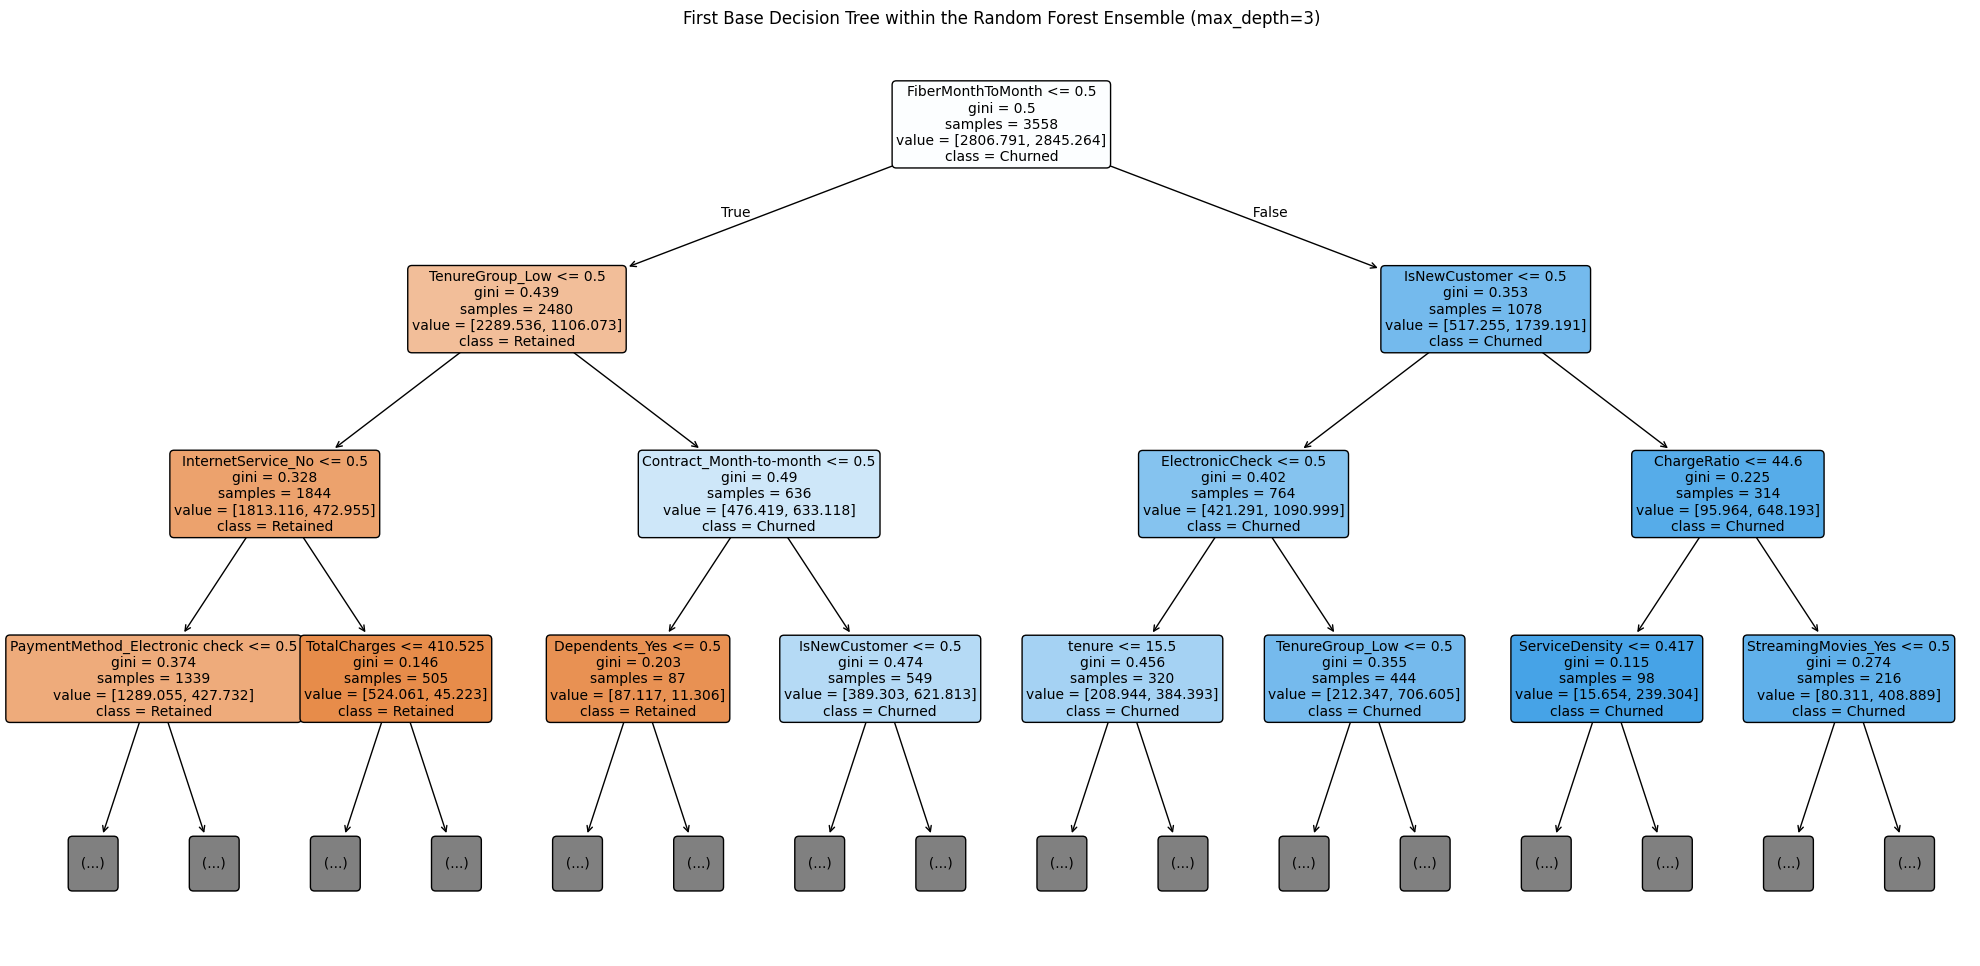

In [ ]:
# Cell 13: Visualize Decision Tree Architecture
print("=== Model Architecture Visualization ===\n")
print(f"Model Type: Random Forest Classifier")

# Print Random Forest configuration
print("\n--- Random Forest Configuration ---")
params = best_rf.get_params()
for key, value in params.items():
    if value is not None and not callable(value):
        print(f"{key}: {value}")

# Visualize first tree in the forest
plt.figure(figsize=(25, 12))
plot_tree(
    best_rf.estimators_[0],  # Using best_rf
    max_depth=3,
    feature_names=list(X.columns),
    class_names=['Retained', 'Churned'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("First Base Decision Tree within the Random Forest Ensemble (max_depth=3)")
plt.show()

=== Feature Importance ===

Top 15 Most Important Features:
                       feature  importance
       Contract_Month-to-month    0.113074
             FiberMonthToMonth    0.090246
                        tenure    0.087342
             Contract_Two year    0.061947
                MonthlyCharges    0.057255
                  TotalCharges    0.057136
   InternetService_Fiber optic    0.052822
               AvgMonthlySpend    0.046653
                   ChargeRatio    0.045555
                  IsLongTenure    0.033878
PaymentMethod_Electronic check    0.032914
               TenureGroup_Low    0.027760
               ElectronicCheck    0.026974
                 IsNewCustomer    0.024561
            InternetService_No    0.021251


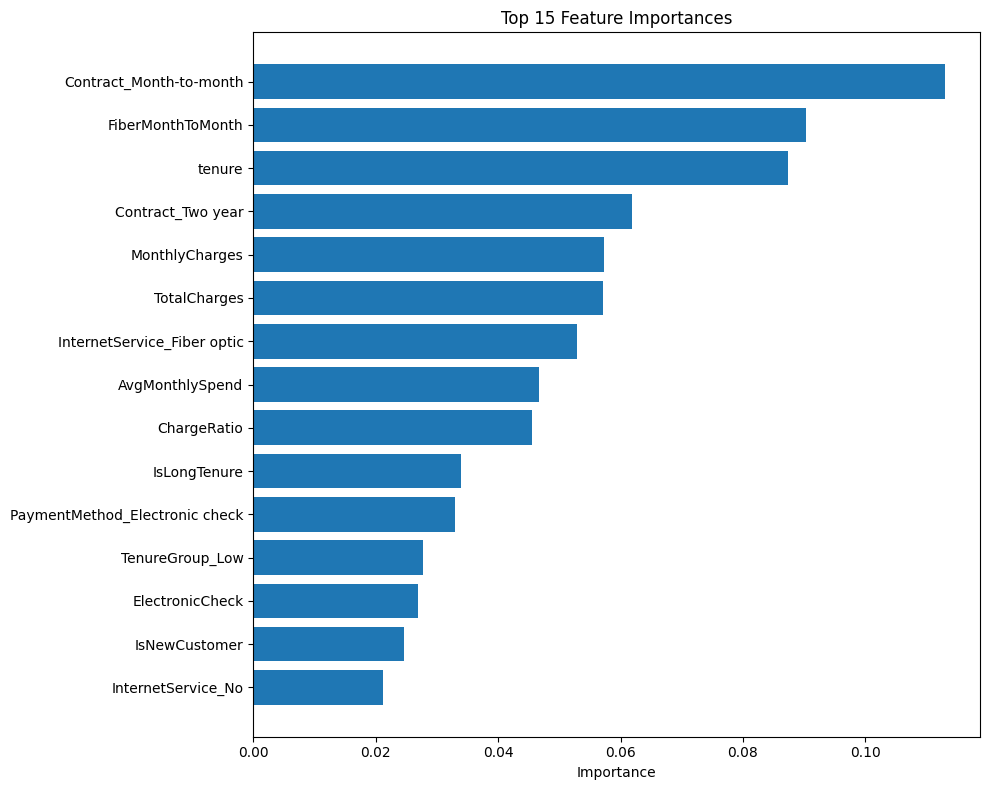

In [ ]:
# Cell 14: Feature Importance Analysis
print("=== Feature Importance ===\n")

importances = best_rf.feature_importances_  # Using best_rf

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

# Show top 15 features
print("Top 15 Most Important Features:")
print(feature_importance_df.head(15).to_string(index=False))

# Plot top features
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Cell 15: Save Model and Artifacts
print("=== Saving Model for Deployment ===\n")

# Save the best model (best_rf)
joblib.dump(best_rf, 'churn_model.pkl')
print("✓ Saved model: churn_model.pkl")

# Save column names (needed for prediction)
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')
print("✓ Saved column names: model_columns.pkl")

# Save the best threshold
joblib.dump(best_threshold, 'best_threshold.pkl')
print(f"✓ Saved best threshold: {best_threshold}")

print("\nAll files saved successfully! Ready for Hugging Face deployment.")

=== Saving Model for Deployment ===

✓ Saved model: churn_model.pkl
✓ Saved column names: model_columns.pkl
✓ Saved best threshold: 0.45

All files saved successfully! Ready for Hugging Face deployment.
